# Capítulo 17 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 17. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Omega = 9.8, 7.292e-5
f = 2*Omega*np.sin(np.deg2rad(-23.5))

## T1 — Teorema de circulação e a brisa

**Solução.** No circuito vertical costa–mar, a taxa de geração de circulação é o termo solenoidal de Bjerknes:
$$\frac{d\Gamma}{dt} = -\oint \frac{dP}{\rho}.$$
Sobre a terra quente o ramo vertical atravessa ar menos denso; sobre o mar frio, mais denso: a integral não se anula e gira o circuito no sentido mar→terra embaixo. Com $\Delta T \sim 5$ K numa coluna de 1 km e circuito de 40 km, $d\Gamma/dt \sim R_d\,\Delta T\,\ln(P_0/P_1) \sim 10^2$ m²/s² por segundo — uma brisa de ~5 m/s se monta em ~1 h, freada pelo atrito no equilíbrio do Caso 1. ∎

## T2 — Equilíbrio catabático

In [2]:
u, dth, th, al, CD_, h_ = sp.symbols('u Delta_theta theta alpha C_D h', positive=True)
eq = sp.Eq(g*dth/th*sp.sin(al) - CD_/h_*u**2, 0)
ueq = sp.solve(eq, u)[0]
display(sp.Eq(sp.Symbol('u_eq'), ueq))
vals = {dth: 5.0, th: 285.0, al: sp.rad(2), CD_: 5e-3, h_: 50.0}
print(f'encosta de serra (2°, 5 K, 50 m): u_eq = {float(ueq.subs(vals)):.1f} m/s')
vals_ant = {dth: 20.0, th: 250.0, al: sp.rad(0.6), CD_: 2e-3, h_: 300.0}
print(f'Antartida (0,6°, 20 K, 300 m): u_eq = {float(ueq.subs(vals_ant)):.1f} m/s')
print('o segredo antartico nao e inclinacao: e inversao brutal + camada espessa')
print('+ centenas de km de pista (e Coriolis desviando o escoamento — N2).')

Eq(u_eq, 3.13049516849971*sqrt(Delta_theta)*sqrt(h)*sqrt(sin(alpha))/(sqrt(C_D)*sqrt(theta)))

encosta de serra (2°, 5 K, 50 m): u_eq = 7.7 m/s
Antartida (0,6°, 20 K, 300 m): u_eq = 35.1 m/s
o segredo antartico nao e inclinacao: e inversao brutal + camada espessa
+ centenas de km de pista (e Coriolis desviando o escoamento — N2).


## T3 — Parâmetro de Scorer e propagação vertical

**Solução.** A equação linear das ondas de montanha para o deslocamento $\hat\delta(k, z)$ é
$$\frac{d^2\hat\delta}{dz^2} + \left(\ell^2 - k^2\right)\hat\delta = 0,\qquad \ell^2 = \frac{N^2}{U^2} - \frac{U''}{U}.$$
- $k < \ell$ (montanha LARGA): soluções oscilatórias em $z$ — a onda **propaga** para cima (cristas inclinadas contra o vento, energia sobe; Caso 3).
- $k > \ell$ (montanha estreita): soluções evanescentes — a onda morre com a altura.
- $\ell^2$ **decrescendo** com a altura (U aumentando, N caindo): ondas ficam presas num guia — **ondas de sotavento aprisionadas**, o trem periódico das lenticulares (Cap. 6). ∎

## T4 — Froude e o salto hidráulico

**Solução.** Na camada rasa, ondas longas viajam a $c = \sqrt{g'h}$. O número de Froude $Fr = U/c$ compara o escoamento com sua própria onda:
- $Fr < 1$: a informação viaja contra o vento; o fluido "sabe" da montanha e sobe engrossando a montante.
- $Fr > 1$: nada avisa o escoamento; ele afina e ACELERA morro abaixo.
- Transição crítica no topo ($Fr = 1$): a camada despenca supercrítica na descida e devolve a energia num **salto hidráulico** turbulento no sopé — a assinatura da Bora e dos windstorms. A mesma física da pia da cozinha: o disco liso supercrítico e o anel turbulento do salto. ∎

## T5 — O aquecimento föhn

In [3]:
Gd, Gs = 9.8, 5.5                              # K/km
z_lcl, z_topo = 1.0, 3.0                       # km (barlavento)
T0 = 20.0
T_topo = T0 - Gd*z_lcl - Gs*(z_topo - z_lcl)   # sobe: seco até LCL, úmido depois
T_sota = T_topo + Gd*z_topo                     # desce TUDO seco (chuva ficou lá)
print(f'sobe a barlavento: T(topo) = {T_topo:.1f} °C (chovendo na serra)')
print(f'desce a sotavento: T(base) = {T_sota:.1f} °C')
print(f'aquecimento föhn: +{T_sota - T0:.1f} °C — e ar seco')
print()
print('a diferenca vem do L_v que ficou no sotavento: cada g/kg condensado e')
print('removido vale ~2,5 K de aquecimento na descida (Caps. 3-4).')

sobe a barlavento: T(topo) = -0.8 °C (chovendo na serra)
desce a sotavento: T(base) = 28.6 °C
aquecimento föhn: +8.6 °C — e ar seco

a diferenca vem do L_v que ficou no sotavento: cada g/kg condensado e
removido vale ~2,5 K de aquecimento na descida (Caps. 3-4).


---
## N1 — Brisa × vento sinótico oposto

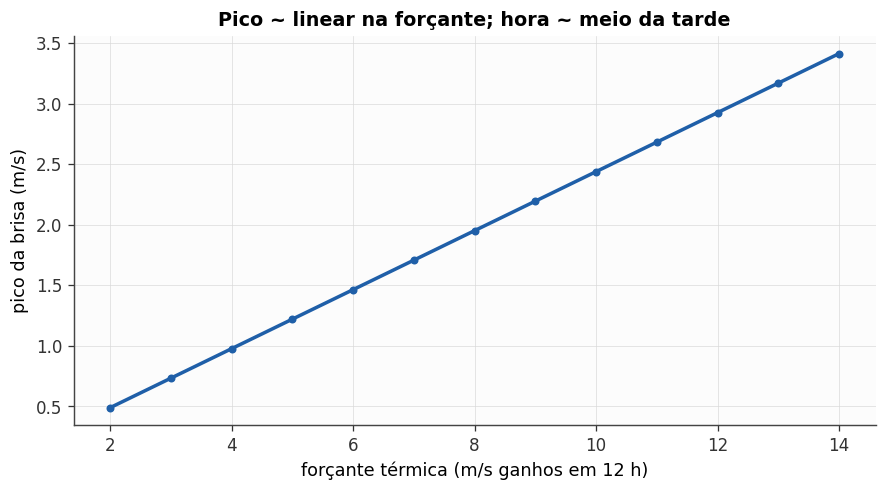

vento sinotico +0 m/s: brisa líquida máx +2.0 m/s (entra)
vento sinotico -3 m/s: brisa líquida máx +0.8 m/s (entra)
vento sinotico -5 m/s: brisa líquida máx +0.0 m/s (entra)
vento sinotico -7 m/s: brisa líquida máx -0.8 m/s (NAO entra)
com ~-6 m/s de oposicao a brisa nao passa da praia — dia abafado na cidade.


In [4]:
tau = 6*3600.0

def pico_brisa(F12, u_sin=0.0):
    F0 = F12/(12*3600)
    def rhs(t, y):
        u, v = y
        hora = (t/3600) % 24
        F = F0*np.sin(np.pi*(hora - 8)/12) if 8 <= hora <= 20 else 0.0
        return [F - (u - u_sin)/tau + f*v, -f*u - v/tau]
    t_eval = np.linspace(24*3600, 48*3600, 400)
    s = solve_ivp(rhs, [0, 48*3600], [u_sin, 0], t_eval=t_eval, rtol=1e-8)
    i = np.argmax(s.y[0])
    return s.y[0][i], (t_eval[i]/3600) % 24

F12s = np.linspace(2, 14, 13)
picos = [pico_brisa(F) for F in F12s]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(F12s, [p[0] for p in picos], 'o-', ms=4, color=CORES['azul'])
ax.set(xlabel='forçante térmica (m/s ganhos em 12 h)', ylabel='pico da brisa (m/s)',
       title='Pico ~ linear na forçante; hora ~ meio da tarde')
plt.show()
for u_s in [0, -3, -5, -7]:
    u_max, hora = pico_brisa(8.0, u_s)
    entra = 'entra' if u_max > 0 else 'NAO entra'
    print(f'vento sinotico {u_s:+.0f} m/s: brisa líquida máx {u_max:+.1f} m/s ({entra})')
print('com ~-6 m/s de oposicao a brisa nao passa da praia — dia abafado na cidade.')

## N2 — Catabático antártico

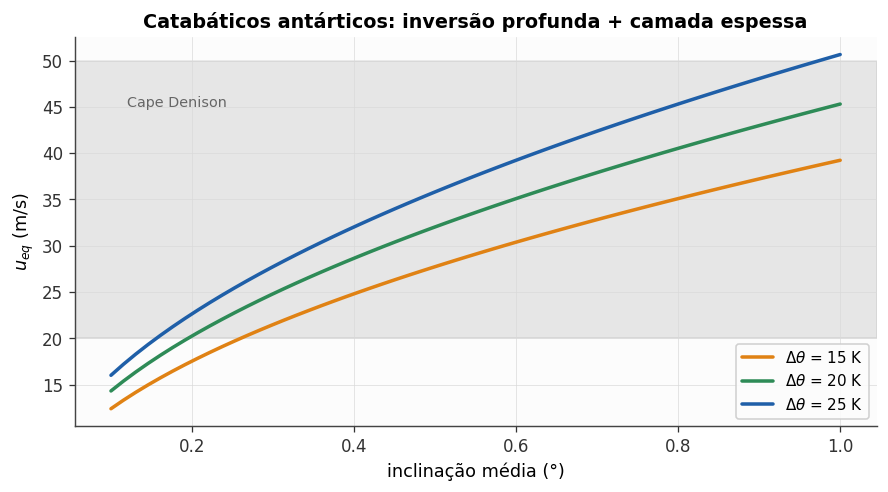

com 0,3-0,6° e 20-25 K chega-se aos 20-40 m/s; convergencia em vales
(Adelie Land) e o empurrao final ate os recordes de ~50 m/s de media.


In [5]:
CD, h, th = 2e-3, 300.0, 250.0
als = np.deg2rad(np.linspace(0.1, 1.0, 60))
fig, ax = plt.subplots(figsize=(9, 4.4))
for dth, cor in [(15, CORES['laranja']), (20, CORES['verde']), (25, CORES['azul'])]:
    ueq = np.sqrt(g*h*dth*np.sin(als)/(CD*th))
    ax.plot(np.rad2deg(als), ueq, color=cor, label=f'$\\Delta\\theta$ = {dth} K')
ax.axhspan(20, 50, color=CORES['cinza'], alpha=0.15)
ax.text(0.12, 45, 'Cape Denison', fontsize=9, color='#666666')
ax.set(xlabel='inclinação média (°)', ylabel='$u_{eq}$ (m/s)',
       title='Catabáticos antárticos: inversão profunda + camada espessa')
ax.legend()
plt.show()
print('com 0,3-0,6° e 20-25 K chega-se aos 20-40 m/s; convergencia em vales')
print('(Adelie Land) e o empurrao final ate os recordes de ~50 m/s de media.')

## N3 — Ressonância vertical das ondas

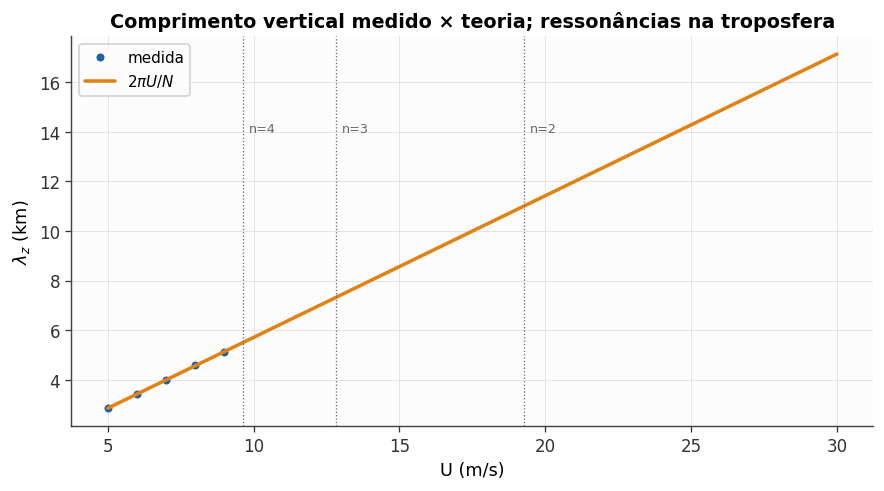

lambda_z = 2 pi U/N confere; a onda "cabe" n meias-voltas na troposfera para
  n = 1: U = 38.5 m/s
  n = 2: U = 19.3 m/s
  n = 3: U = 12.8 m/s


In [6]:
N_bv, H_tropo = 0.011, 11e3
a, h0 = 3000.0, 600.0
x = np.linspace(-20e3, 80e3, 3000)
z = np.linspace(0, 10000, 400)
X, Z = np.meshgrid(x, z)

Us = np.linspace(5, 30, 26)
lam_medida = []
for U in Us:
    l_ = N_bv/U
    iz = np.argmin(np.abs(z - 3000))
    delta = h0*a*(a*np.cos(l_*Z) - X*np.sin(l_*Z))/(X**2 + a**2)
    # distância vertical entre máximos de delta em x fixo (x=10 km):
    ix = np.argmin(np.abs(x - 10e3))
    perfil = h0*a*(a*np.cos(l_*z) - 10e3*np.sin(l_*z))/((10e3)**2 + a**2)
    picos = np.where((perfil[1:-1] > perfil[:-2]) & (perfil[1:-1] > perfil[2:]))[0]
    lam_medida.append(np.mean(np.diff(z[picos + 1])) if picos.size > 1 else np.nan)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(Us, np.array(lam_medida)/1e3, 'o', ms=4, color=CORES['azul'], label='medida')
ax.plot(Us, 2*np.pi*Us/N_bv/1e3, '-', color=CORES['laranja'], label='$2\\pi U/N$')
ns = np.arange(1, 5)
for n in ns:
    U_res = N_bv*H_tropo/(2*np.pi*n)*2  # lambda_z*n/2 = H  (nós no chão e na tropopausa)
    if 5 <= U_res <= 30:
        ax.axvline(U_res, color=CORES['cinza'], ls=':', lw=0.8)
        ax.text(U_res + 0.2, 14, f'n={n}', fontsize=8, color='#666666')
ax.set(xlabel='U (m/s)', ylabel='$\\lambda_z$ (km)',
       title='Comprimento vertical medido × teoria; ressonâncias na troposfera')
ax.legend()
plt.show()
print('lambda_z = 2 pi U/N confere; a onda "cabe" n meias-voltas na troposfera para')
for n in [1, 2, 3]:
    print(f'  n = {n}: U = {2*N_bv*H_tropo/(2*np.pi*n):.1f} m/s')

## N4 — Mapa de regimes de Froude

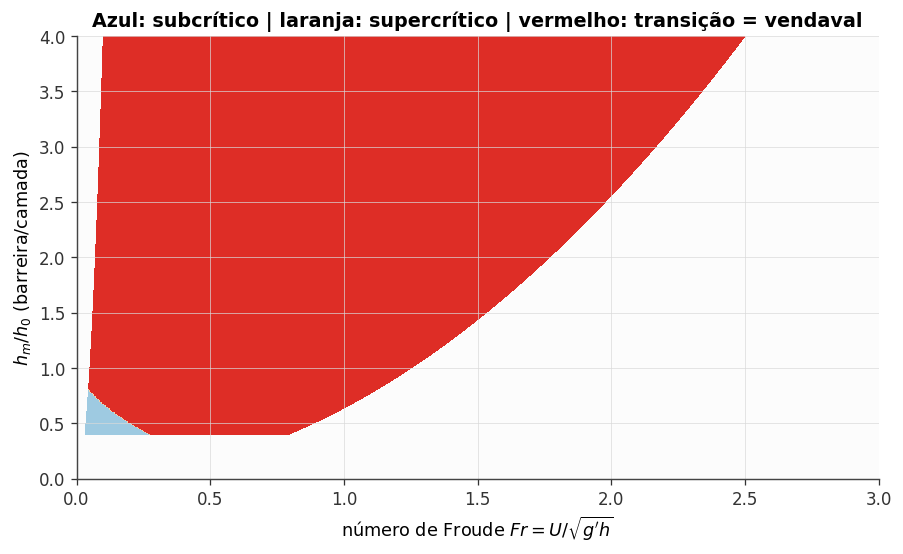

a faixa vermelha (Fr ~ 0,3-1 com barreira comparavel a camada) e onde a
montanha forca a transicao critica: Bora, Boulder windstorms, rajadas de serra.


In [7]:
gp, hm = 0.5, 800.0

def regime(U0, h0):
    Fr = U0/np.sqrt(gp*h0)
    # energia disponível vs barreira: transição crítica se E mal alcança o topo
    E = U0**2/2 + gp*h0
    E_crit = 1.5*(U0*h0*np.sqrt(gp))**(2/3)*gp**(1/3)  # energia mínima no topo (Fr=1)
    if E < E_crit + gp*hm*0.999:
        return 2                                        # bloqueio/transição -> vendaval
    return 0 if Fr < 1 else 1

U0s = np.linspace(1, 25, 120)
h0s = np.linspace(100, 2000, 120)
UU, HH = np.meshgrid(U0s, h0s)
R = np.vectorize(regime)(UU, HH)
Fr = UU/np.sqrt(gp*HH)

fig, ax = plt.subplots(figsize=(9, 5))
cf = ax.contourf(Fr, hm/HH, R, levels=[-0.5, 0.5, 1.5, 2.5],
                 colors=['#9ecae1', '#fdd0a2', '#de2d26'])
ax.set(xlabel='número de Froude $Fr = U/\\sqrt{g\'h}$', xlim=(0, 3),
       ylabel='$h_m/h_0$ (barreira/camada)', ylim=(0, 4),
       title='Azul: subcrítico | laranja: supercrítico | vermelho: transição = vendaval')
plt.show()
print('a faixa vermelha (Fr ~ 0,3-1 com barreira comparavel a camada) e onde a')
print('montanha forca a transicao critica: Bora, Boulder windstorms, rajadas de serra.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*